In [29]:
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split

In [30]:
df = pd.read_csv('../data/features/features_complete.csv')

In [31]:
df.columns

Index(['index', 'video_id', 'trending_date', 'title', 'channel_title',
       'category_id', 'publish_date', 'time_frame', 'published_day_of_week',
       'publish_country', 'tags', 'views', 'likes', 'dislikes',
       'comment_count', 'comments_disabled', 'ratings_disabled',
       'video_error_or_removed', 'category_name', 'is_published_weekend',
       'trending_day_of_week', 'is_trending_weekend', 'hour_of_trending',
       'days_until_trending', 'title_cleaned', 'title_length',
       'uppercase_words', 'contains_numbers_or_emojis', 'num_emojis',
       'has_emoji', 'emojis_list', 'sentiment_polarity',
       'sentiment_subjectivity', 'is_title_english', 'top50_pca1',
       'top50_pca2', 'top50_pca3', 'published_day_of_week_num'],
      dtype='object')

In [37]:
features = [
    # --- Existing features ---
    'title_length', 
    'uppercase_words', 
    'sentiment_polarity', 
    'sentiment_subjectivity',
    'category_id',  
    'published_day_of_week_num',
    'hour_of_trending',       # Time of day
    'days_until_trending',    # How long to trend
    'num_emojis',
    'has_emoji',
    'contains_numbers_or_emojis',
    'comments_disabled',
    'ratings_disabled',
    'is_title_english',             # Title language flag

    'top50_pca1',             # PCA embedding of top 50 words
    'top50_pca2',
    'top50_pca3',

    # --- Metadata / flags ---
    'is_published_weekend',   # True if video published on weekend
    'is_trending_weekend',    # True if trending on weekend
   
]

X = df[features]
y = np.log1p(df['views'])
print(f"Shape: X={X.shape}, y={y.shape}")

Shape: X=(55886, 19), y=(55886,)


In [38]:

X_train, X_test, y_train, y_test  = train_test_split(X,y,test_size=0.2, random_state=42)

In [39]:
# Mean Predictor Baseline Model
y_mean = y_train.mean()
y_pred = np.full(len(y_test),y_mean)
print(f"Mean Baseline Model predicts: {y_mean:,.0f} views for every video")

Mean Baseline Model predicts: 11 views for every video


In [40]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\nBaseline Mean Model Performance (LOG SCALE):")
print(f"RMSE: {rmse:.4f}")  # ← Changed from :.0f to :.4f
print(f"MAE:  {mae:.4f}")   # ← Changed from :.0f to :.4f
print(f"R²:   {r2:.4f}")


Baseline Mean Model Performance (LOG SCALE):
RMSE: 1.6782
MAE:  1.3909
R²:   -0.0000


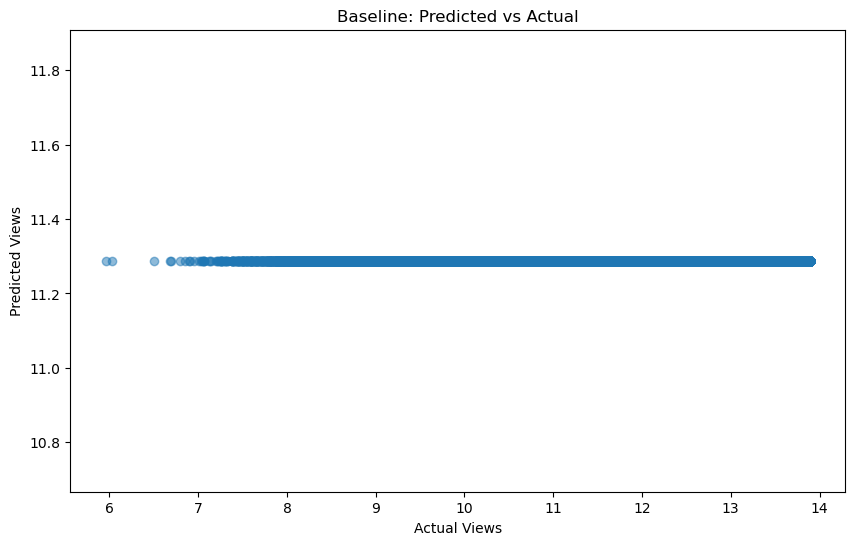

In [36]:
import matplotlib.pyplot as plt

# Scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.xlabel('Actual Views')
plt.ylabel('Predicted Views')
plt.title('Baseline: Predicted vs Actual')
plt.savefig('../reports/baseline_model/baseline_predictions.png')
plt.show()